In [5]:
# Levi Félix Barbosa - 579420

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

np.random.seed(42)

In [6]:
dados = np.loadtxt('californiabin.csv', delimiter=',')
X, y = dados[:, :8], dados[:, 8].astype(int)



X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)


In [7]:
C_grid     = [2.0**e for e in [-5, -3, -1, 1, 3, 5, 7, 9, 11, 13, 15]]
gamma_grid = [2.0**e for e in [-15, -13, -11, -9, -7, -5, -3, -1, 1, 2, 3]]

# ja que pode scikit, fiz logo um pipeline
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

grade_svm = {'svc__C': C_grid, 'svc__gamma': gamma_grid}

gs_svm = GridSearchCV(pipe_svm, grade_svm, cv=10, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_treino, y_treino)

print('Melhores hiperparâmetros (SVM):')
print('  C     =', gs_svm.best_params_['svc__C'])
print('  gamma =', gs_svm.best_params_['svc__gamma'])
print('  acurácia média na CV = %.4f' % gs_svm.best_score_)

svm_final = gs_svm.best_estimator_   # ja re-treinado em todo o treino (treino+validação)

Melhores hiperparâmetros (SVM):
  C     = 32768.0
  gamma = 0.001953125
  acurácia média na CV = 0.8556


In [8]:
n_est_grid = list(range(10, 201, 10))
depth_grid = [4, 6, 8, 10, None]

grade_rf = {'n_estimators': n_est_grid, 'max_depth': depth_grid}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     grade_rf, cv=10, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_treino, y_treino)

print('Melhores hiperparâmetros (Random Forest):')
print('  n_estimators =', gs_rf.best_params_['n_estimators'])
print('  max_depth    =', gs_rf.best_params_['max_depth'])
print('  acurácia média na CV = %.4f' % gs_rf.best_score_)

rf_final = gs_rf.best_estimator_

Melhores hiperparâmetros (Random Forest):
  n_estimators = 60
  max_depth    = None
  acurácia média na CV = 0.8644


In [9]:
def avaliar(nome, modelo, escores):
    y_pred = modelo.predict(X_teste)
    return {
        'modelo':    nome,
        'acuracia':  accuracy_score(y_teste, y_pred),
        'revocacao': recall_score(y_teste, y_pred),
        'precisao':  precision_score(y_teste, y_pred),
        'f1':        f1_score(y_teste, y_pred),
        'auroc':     roc_auc_score(y_teste, escores),
        'auprc':     average_precision_score(y_teste, escores),
        'escores':   escores,
    }

res_svm = avaliar('SVM (RBF)', svm_final, svm_final.decision_function(X_teste))
res_rf  = avaliar('Random Forest', rf_final, rf_final.predict_proba(X_teste)[:, 1])

print('%-15s %8s %9s %8s %7s %7s %7s' %
      ('Modelo', 'Acuracia', 'Revocacao', 'Precisao', 'F1', 'AUROC', 'AUPRC'))
for r in (res_svm, res_rf):
    print('%-15s %8.4f %9.4f %8.4f %7.4f %7.4f %7.4f' %
          (r['modelo'], r['acuracia'], r['revocacao'], r['precisao'],
           r['f1'], r['auroc'], r['auprc']))

Modelo          Acuracia Revocacao Precisao      F1   AUROC   AUPRC
SVM (RBF)         0.8450    0.8400   0.8485  0.8442  0.9301  0.9336
Random Forest     0.8775    0.8500   0.8995  0.8740  0.9518  0.9523


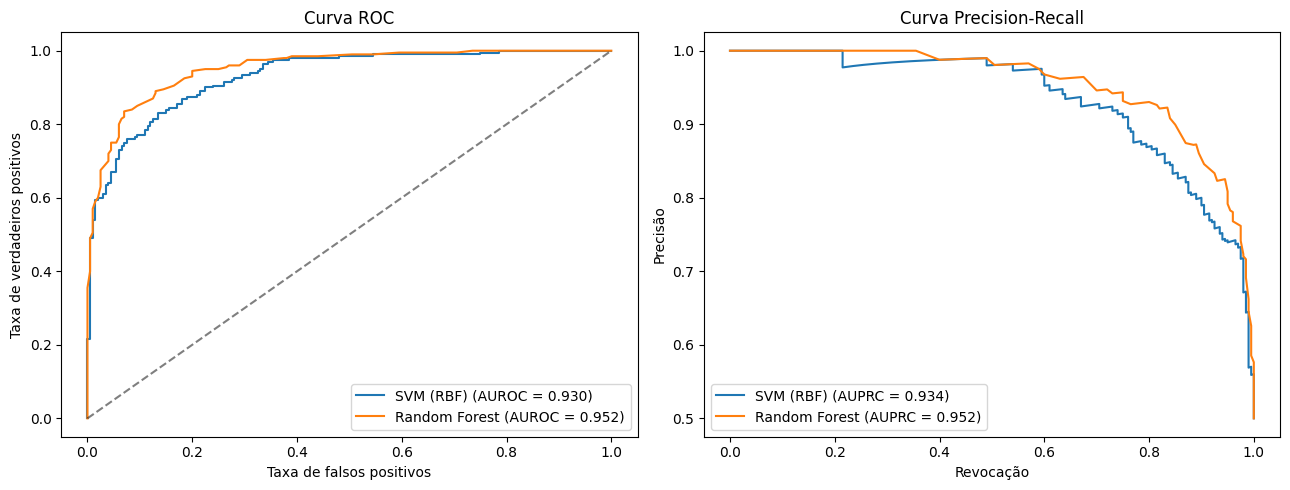

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ROC 
for r, cor in [(res_svm, 'C0'), (res_rf, 'C1')]:
    fpr, tpr, _ = roc_curve(y_teste, r['escores'])
    ax1.plot(fpr, tpr, color=cor, label="%s (AUROC = %.3f)" % (r['modelo'], r['auroc']))
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('Taxa de falsos positivos'); ax1.set_ylabel('Taxa de verdadeiros positivos')
ax1.set_title('Curva ROC'); ax1.legend(loc='lower right')

# PR
for r, cor in [(res_svm, 'C0'), (res_rf, 'C1')]:
    prec, rec, _ = precision_recall_curve(y_teste, r['escores'])
    ax2.plot(rec, prec, color=cor, label="%s (AUPRC = %.3f)" % (r['modelo'], r['auprc']))
ax2.set_xlabel('Revocação'); ax2.set_ylabel('Precisão')
ax2.set_title('Curva Precision-Recall'); ax2.legend(loc='lower left')

plt.tight_layout(); plt.show()